## Martyna Gaj, Michał Dworniczak

# Projekt 5: Uczenie przez wzmacnianie w przestrzeniach ciągłych

**Autorzy:** Michał Dworniczak, Martyna Gaj  
**Data:** 2026-05-28

**Streszczenie:** W projekcie badamy zachowanie algorytmu Proximal Policy Optimization (PPO) w środowisku LunarLanderContinuous (Gymnasium). Przeprowadzono eksperymenty z kilkoma zestawami hiperparametrów oraz porównano różne architektury sieci neuronowych. Końcowo wykonano ewaluację najlepszego modelu w trybie deterministycznym i porównano wyniki z krzywą treningową.

# Importy

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
import os
import torch.nn as nn
import json
import shutil
import matplotlib.image as mpimg
from IPython.display import Image, display

# Za 4 punkty

### Stałe

In [2]:
env_id = "LunarLander-v3"
total_timesteps = 100000
n_runs = 10

### Zestawy parametrów

## Charakterystyka środowiska i algorytmu (Zad. na 4 pkt)

### Środowisko Gymnasium: LunarLanderContinuous-v3
Środowisko `LunarLanderContinuous-v3` modeluje problem sterowania lądownikiem w przestrzeni ciągłej. Obserwacje to wektor 8-wymiarowy (pozycja, prędkości, kąt, prędkość kątowa, kontakty nóżek). Akcje to wektor 2-wymiarowy z przedziału [-1, 1]: ciąg silnika głównego oraz sterowanie boczne. Główne wyzwania: nieliniowa dynamika, konieczność oszczędzania paliwa i precyzyjne sterowanie.

### Algorytm: PPO (Proximal Policy Optimization)
PPO to metoda on-policy z rodziny metod gradientu polityki. Kluczowa cecha to funkcja celu z obcinaniem (clipping), która ogranicza zbyt duże zmiany polityki podczas aktualizacji, co poprawia stabilność uczenia. PPO uczy jednocześnie polityki (Aktor) i funkcji wartości (Krytyk).

In [3]:
hyperparams_sets = [
    {"name": "Set 1 (Default)", "lr": 3e-4, "batch_size": 64},
    {"name": "Set 2 (Fast/Large)", "lr": 1e-3, "batch_size": 128},
    {"name": "Set 3 (Slow/Small)", "lr": 5e-5, "batch_size": 32}
]

### Trening dla różnych zestawów hiperparametrów

In [4]:
log_dir = "./logs"
os.makedirs(log_dir, exist_ok=True)

results = {}
execution_times = []

for hp in hyperparams_sets:
    print(f"Starting: {hp['name']}")
    all_runs_rewards = []

    for run in range(n_runs):
        env = gym.make(env_id, continuous=True)

        run_log_dir = f"{log_dir}/{hp['name']}_run_{run}"
        os.makedirs(run_log_dir, exist_ok=True)
        env = Monitor(env, run_log_dir)

        model = PPO(
            "MlpPolicy",
            env,
            learning_rate=hp["lr"],
            batch_size=hp["batch_size"],
            seed=run,
            verbose=1,
            device="cuda"
        )

        start_time = time.time()
        model.learn(total_timesteps=total_timesteps)
        model.save(f"ppo_lunar_{hp['name']}_run_{run}")
        end_time = time.time()

        execution_times.append((end_time - start_time) / total_timesteps)

        x, y = ts2xy(load_results(run_log_dir), "timesteps")

        eval_steps = np.linspace(0, total_timesteps, 100)
        y_interp = np.interp(eval_steps, x, y)
        all_runs_rewards.append(y_interp)

        env.close()

    results[hp["name"]] = {
        "steps": eval_steps,
        "mean": np.mean(all_runs_rewards, axis=0),
        "std": np.std(all_runs_rewards, axis=0)
    }

Starting: Set 1 (Default)


c:\Users\marty\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 104      |
|    ep_rew_mean     | -243     |
| time/              |          |
|    fps             | 908      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 118          |
|    ep_rew_mean          | -272         |
| time/                   |              |
|    fps                  | 583          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0062158685 |
|    clip_fraction        | 0.0539       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    e

c:\Users\marty\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\save_util.py:284: UserWarning: Path 'ppo_lunar_Set 2 (Fast' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 126      |
|    ep_rew_mean     | -258     |
| time/              |          |
|    fps             | 836      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 126          |
|    ep_rew_mean          | -235         |
| time/                   |              |
|    fps                  | 703          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0073082075 |
|    clip_fraction        | 0.0802       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.87        |
|    e

c:\Users\marty\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\save_util.py:284: UserWarning: Path 'ppo_lunar_Set 3 (Slow' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 126      |
|    ep_rew_mean     | -258     |
| time/              |          |
|    fps             | 872      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 132          |
|    ep_rew_mean          | -256         |
| time/                   |              |
|    fps                  | 471          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0025149314 |
|    clip_fraction        | 0.0062       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    e

### Wizualizacja procesu uczenia

## Analiza hiperparametrów i krzywe uczenia (Zad. na 4 pkt)

Przetestowano trzy zestawy hiperparametrów, dla każdego wykonano `10` niezależnych uruchomień (różne ziarna). Każde uruchomienie obejmowało `100000` kroków czasowych.

**Zestawy hiperparametrów (skrót):**

| Hiperparametr | Set 1 (Default) | Set 2 (Fast/Large) | Set 3 (Slow/Small) |
|---:|:---:|:---:|:---:|
| Learning rate | 3e-4 | 1e-3 | 5e-5 |
| Batch size | 64 | 128 | 32 |
| Gamma | 0.99 | 0.99 | 0.99 |
| n_steps | 2048 | 2048 | 2048 |

Na rysunku z krzywymi (`learning_curves.png`) pokazano uśrednione krzywe uczenia wraz z pasmem ±1 sigma z 10 powtórzeń.

Average time per timestep: 0.002396 seconds


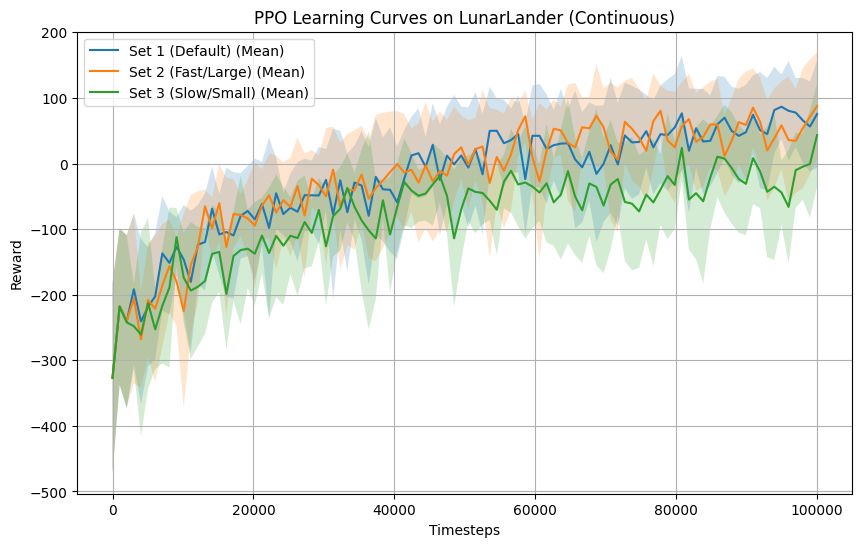

In [5]:
avg_step_time = np.mean(execution_times)
print(f"Average time per timestep: {avg_step_time:.6f} seconds")

plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data["steps"], data["mean"], label=f"{name} (Mean)")
    plt.fill_between(
        data["steps"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("PPO Learning Curves on LunarLander (Continuous)")
plt.legend()
plt.grid(True)
plt.savefig("learning_curves.png")
plt.show()

Zestaw domyślny oraz zestaw ze zwiększonymi batch size oraz learning rate osiągnęły podobne wyniki. Zestaw z mniejszymi wartościami tych parametrów okazał się być nieco gorszy podczas całości procesu uczenia.

# Za 6 punktów

### Architektury sieci

## Architektury sieci neuronowych (Zad. na 6 pkt)

Dla porównania przebadano dwie architektury MLP:

- Architektura 1 (Standardowa): dwie warstwy ukryte po 256 neurony, aktywacja `tanh`.
- Architektura 2 (Głęboka/Szeroka): dwie warstwy ukryte po 256 neurony, aktywacja `ReLU`.

Wejście: wektor 8-wymiarowy (obserwacje). Wyjście: wektor 2-wymiarowy (akcje). Wyniki porównano na wykresie `architecture_comparison.png`.

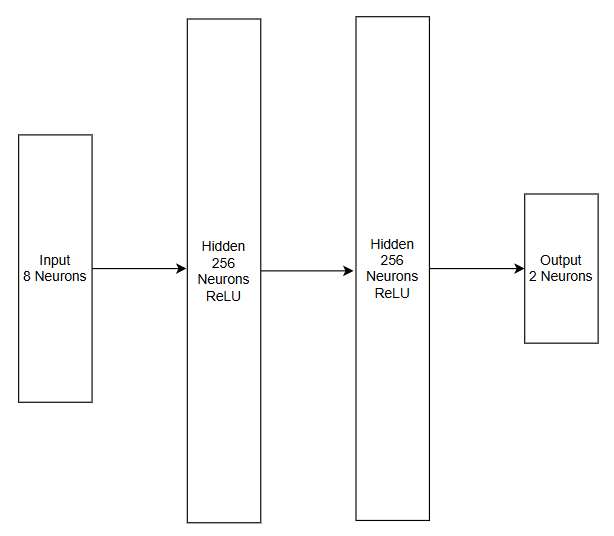

In [3]:
display(Image(filename='ReLU_Architecture.png'))

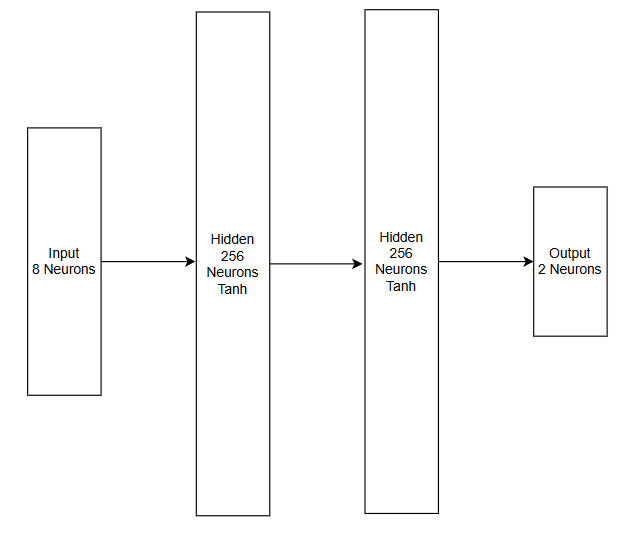

In [4]:
display(Image(filename='Tanh_Architecture.png'))

In [6]:
architectures = [
    {
        "name": "Architecture_256x256_ReLU",
        "policy_kwargs": dict(
            net_arch=dict(pi=[256, 256], vf=[256, 256]),
            activation_fn=nn.ReLU
        )
    },
    {
        "name": "Architecture_256x256_Tanh",
        "policy_kwargs": dict(
            net_arch=dict(pi=[256, 256], vf=[256, 256]),
            activation_fn=nn.Tanh
        )
    }
]

### Uczenie różnych architektur

In [7]:
log_dir = "./logs_architecture"
os.makedirs(log_dir, exist_ok=True)

results = {}
execution_times = []

for arch in architectures:
    print(f"Starting architecture test: {arch['name']}")
    all_runs_rewards = []

    for run in range(n_runs):
        print(f"  - Run {run}/{n_runs}")
        env = gym.make(env_id, continuous=True)

        run_log_dir = f"{log_dir}/{arch['name']}_run_{run}"
        os.makedirs(run_log_dir, exist_ok=True)
        env = Monitor(env, os.path.join(run_log_dir, "monitor.csv"))

        model = PPO(
            "MlpPolicy",
            env,
            learning_rate=0.0003,
            batch_size=64,
            seed=run,
            policy_kwargs=arch["policy_kwargs"],
            verbose=1,
            device="cuda"
        )

        start_time = time.time()
        model.learn(total_timesteps=total_timesteps)
        model.save(f"ppo_lunar_{arch['name']}_run_{run}")
        end_time = time.time()

        execution_times.append((end_time - start_time) / total_timesteps)

        x, y = ts2xy(load_results(run_log_dir), "timesteps")
        eval_steps = np.linspace(0, total_timesteps, 100)
        y_interp = np.interp(eval_steps, x, y)
        all_runs_rewards.append(y_interp)

        env.close()

    results[arch["name"]] = {
        "steps": eval_steps,
        "mean": np.mean(all_runs_rewards, axis=0),
        "std": np.std(all_runs_rewards, axis=0)
    }

Starting architecture test: Architecture_256x256_ReLU
  - Run 0/10
Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 119      |
|    ep_rew_mean     | -266     |
| time/              |          |
|    fps             | 739      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 119        |
|    ep_rew_mean          | -241       |
| time/                   |            |
|    fps                  | 490        |
|    iterations           | 2          |
|    time_elapsed         | 8          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.00336158 |
|    clip_fraction        | 0.0349     |
|    clip_range           | 0.2        |
|    ent

KeyboardInterrupt: 

### Wizualizacja

In [ ]:
print(f"Average time per timestep: {np.mean(execution_times):.6f} seconds")

plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data["steps"], data["mean"], label=f"{name} (Mean)")
    plt.fill_between(data["steps"], data["mean"] - data["std"], data["mean"] + data["std"], alpha=0.15)

plt.title("PPO Architecture Comparison on LunarLander (Continuous)")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.savefig("architecture_comparison.png")
plt.show()

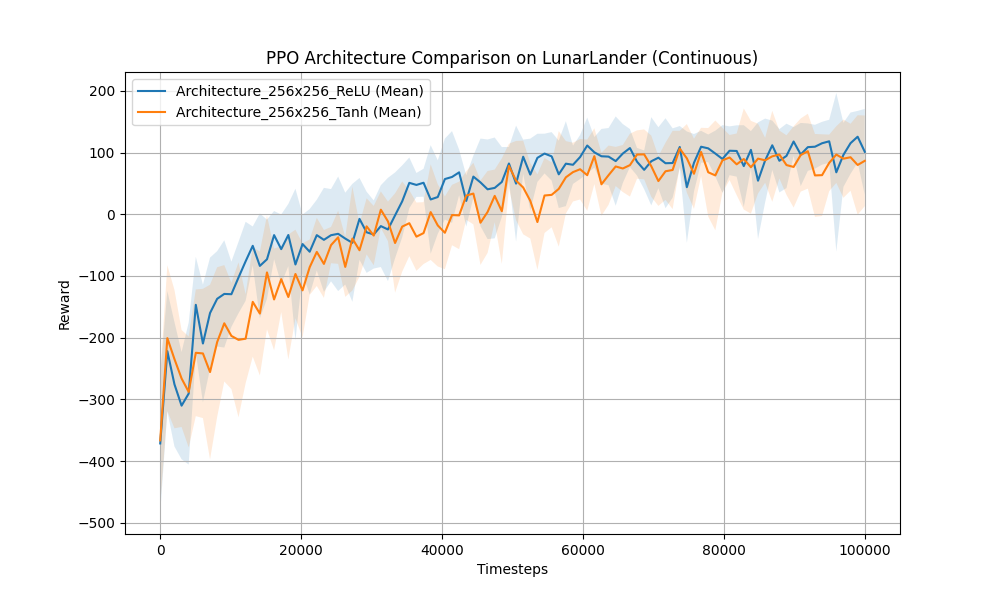

In [2]:
display(Image(filename='architecture_comparison.png'))

W pierwszej połowie treningu sieć używająca ReLU ma przewagę nad architekturą z tanh. Pod koniec treningu sieci osiągją już zbliżone wyniki.

# Zadanie na 8 punktów
Zapisz stan agenta z wcześniejszych zadań dającego najlepsze wyniki. Wykonaj symulację
jego działania z wyłączonym trybem eksploracji (wykonuje deterministycznie najlepsze
akcje). Porównaj nagrody z krzywą uzyskaną w trakcie uczenia. 

### Ocena modelu i symulacja deterministyczna

W tej sekcji oceniamy wytrenowane modele PPO w środowisku LunarLander-v3, zapisujemy wyniki i porównujemy je z uzyskaną krzywą treningową.

## Symulacja deterministyczna i ewaluacja (Zad. na 8 pkt)

Najlepszy model zapisano i przetestowano w trybie deterministycznym (50 epizodów). Ocena polega na wyłączeniu eksploracji (`deterministic=True`) i zapisaniu uzyskanych nagród. Porównano wyniki z krzywą treningową oraz zapisano raport i wykresy w katalogu `models/Default/eval`.

**Wnioski (przykładowe obserwacje):**
- Wyłączenie eksploracji zwykle zwiększa średnią nagrodę, ponieważ agent wykonuje deterministycznie najbardziej preferowane akcje.
- Nadal mogą występować sporadyczne niepowodzenia spowodowane losowymi warunkami początkowymi środowiska.

In [9]:
def eval_model(model, env, n_episodes=50):
    rewards = []
    for ep in range(n_episodes):
        reset_res = env.reset()
        obs = reset_res[0] if isinstance(reset_res, tuple) else reset_res
        done = False
        ep_r = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            try:
                action_arr = np.asarray(action)
                if hasattr(env.action_space, 'shape') and env.action_space.shape is not None and len(env.action_space.shape) > 0:
                    desired = env.action_space.shape
                    if action_arr.shape != desired:
                        try:
                            action = action_arr.reshape(desired)
                        except Exception:
                            if action_arr.size == 1:
                                action = action_arr.flatten()
                            else:
                                action = action_arr
                    else:
                        action = action_arr
                else:
                    if action_arr.shape == () or action_arr.size == 1:
                        action = float(action_arr.flatten()[0])
                    else:
                        action = action_arr.tolist()
            except Exception:
                pass
            
            step_res = env.step(action)
            if len(step_res) == 5:
                obs, reward, terminated, truncated, _ = step_res
                done = terminated or truncated
            else:
                obs, reward, done, _ = step_res
            ep_r += float(reward)
        rewards.append(ep_r)
    return np.array(rewards)

Loading models/Default\best_model.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_0.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_1.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_2.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_3.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_4.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_5.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_6.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_7.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_8.zip ...
Loading models/Default\ppo_lunar_Set 1 (Default)_run_9.zip ...
Best model: best_model.zip with mean reward 180.31
Failed to copy best model: [WinError 32] Proces nie może uzyskać dostępu do pliku, ponieważ jest on używany przez inny proces


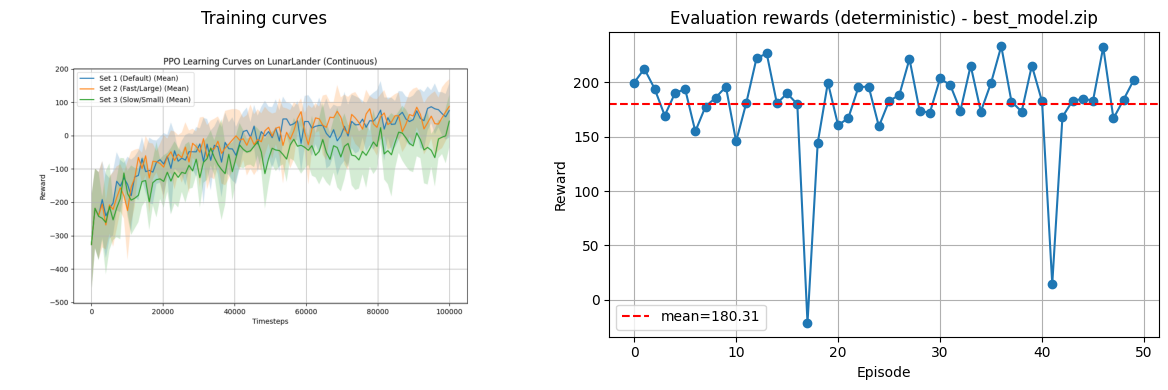

Done. Best model: best_model.zip. Results in models/Default\eval


In [13]:
# Ocena wytrenowanych modeli w trybie deterministycznym
import json
env_id = "LunarLander-v3"
models_dir = "models/Default"
training_curve = "learning_curves.png"
n_episodes = 50

out_dir = os.path.join(models_dir, "eval")
os.makedirs(out_dir, exist_ok=True)

if PPO is None:
    raise ImportError('stable_baselines3 is required for evaluation.')
if gym is None:
    raise ImportError('gymnasium is required for evaluation.')

if not os.path.isdir(models_dir):
    raise FileNotFoundError(f'Models directory {models_dir} not found.')

model_files = [f for f in os.listdir(models_dir) if f.endswith('.zip') or f.endswith('.pkl')]
if not model_files:
    raise FileNotFoundError(f'No model files found in {models_dir}')

env = gym.make(env_id, continuous=True) if env_id.startswith('LunarLander') else gym.make(env_id)

summary = {}
for mf in model_files:
    path = os.path.join(models_dir, mf)
    print(f'Loading {path} ...')
    try:
        model = PPO.load(path)
    except Exception as e:
        print(f'Failed to load {mf}: {e}')
        continue

    rewards = eval_model(model, env, n_episodes=n_episodes)
    summary[mf] = {
        'mean': float(np.mean(rewards)),
        'std': float(np.std(rewards)),
        'rewards': rewards.tolist()
    }
    np.savetxt(os.path.join(out_dir, f'{mf}_rewards.csv'), rewards, delimiter=',')

env.close()

if not summary:
    raise RuntimeError('No models could be loaded and evaluated.')

best_name, best_stats = max(summary.items(), key=lambda kv: kv[1]['mean'])
print(f'Best model: {best_name} with mean reward {best_stats["mean"]:.2f}')

best_path = os.path.join(models_dir, best_name)
best_copy = os.path.join(models_dir, 'best_model.zip')
try:
    shutil.copy2(best_path, best_copy)
    print(f'Copied best model to {best_copy}')
except Exception as e:
    print(f'Failed to copy best model: {e}')

with open(os.path.join(out_dir, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

# Porównanie krzywej treningowej z oceną modelu
rewards = np.array(best_stats['rewards'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if os.path.isfile(training_curve):
    img = mpimg.imread(training_curve)
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title('Training curves')
else:
    axes[0].set_title('Training curves (not found)')
    axes[0].text(0.5, 0.5, 'No training curve image found', ha='center')
    axes[0].axis('off')

axes[1].plot(rewards, marker='o')
axes[1].axhline(np.mean(rewards), color='r', linestyle='--', label=f"mean={np.mean(rewards):.2f}")
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Reward')
axes[1].set_title(f'Evaluation rewards (deterministic) - {best_name}')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
out_png = os.path.join(out_dir, f'comparison_{best_name}.png')
plt.savefig(out_png)
plt.show()
plt.close()

with open(os.path.join(out_dir, 'report.txt'), 'w') as f:
    f.write(f'Best model: {best_name}\n')
    f.write(f'Mean reward (eval): {best_stats["mean"]:.2f}\n')
    f.write(f'Std reward (eval): {best_stats["std"]:.2f}\n')
    if os.path.isfile(training_curve):
        f.write(f'Training curve image: {training_curve}\n')

print(f'Done. Best model: {best_name}. Results in {out_dir}')